# Proyek Klasifikasi Gambar: Fruits Classification

- **Nama:** Fadhilah Nurrahmayanti
- **Email:** a117xbm150@devacademy.id
- **ID Dicoding:** dilaafn

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install pipreqs
!pip install tensorflowjs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.2 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=d530caea80caf286d22e37ce0ee5997863f69749511beefb7b7fc13300b7ec6b
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built docopt
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.12.3 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [1]:
import os, shutil, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
from tqdm.notebook import tqdm
from tqdm import tqdm
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image
from skimage import io, img_as_ubyte
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma
from skimage.util import random_noise
from sklearn.utils import class_weight

import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras import Sequential, layers, applications, optimizers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (InputLayer, Conv2D, SeparableConv2D, MaxPooling2D,
                                     Dense, Flatten, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import MobileNet, DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files, userdata

In [2]:
print(tf.__version__)

2.18.0


## Data Preparation

### Data Loading

upload kaggle.json

In [3]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fadhilaanr","key":"b346a2eb4f8714b9b9d0d1f140515e90"}'}

In [4]:
!rm -rf fruits-classification/

In [5]:
!kaggle datasets download -d utkarshsaxenadn/fruits-classification

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1734, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [6]:
!unzip fruits-classification.zip -d fruits-classification

Streaming output truncated to the last 5000 lines.
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1950).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1952).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1953).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1955).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1956).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1957).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1958).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1959).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (196).jpeg  
  inflating: fruits-classification/Fruits Classification/train/Grape/Grape (1960).jpeg  
  inflating: fruits-classification/Fruits Classification/tra

### Data Preprocessing

In [7]:
train_dir = "fruits-classification/Fruits Classification/train"
test_dir = "fruits-classification/Fruits Classification/test"
valid_dir = "fruits-classification/Fruits Classification/valid"

combined_dir = "fruits-classification/dataset_combined"
os.makedirs(combined_dir, exist_ok=True)

def copy_data(source_dir, target_dir):
    for category in os.listdir(source_dir):
        category_dir = os.path.join(source_dir, category)
        if os.path.isdir(category_dir):
            shutil.copytree(category_dir, os.path.join(target_dir, category), dirs_exist_ok=True)

copy_data(train_dir, combined_dir)
copy_data(test_dir, combined_dir)
copy_data(valid_dir, combined_dir)

print("Dataset berhasil digabung ke dalam:", combined_dir)

Dataset berhasil digabung ke dalam: fruits-classification/dataset_combined


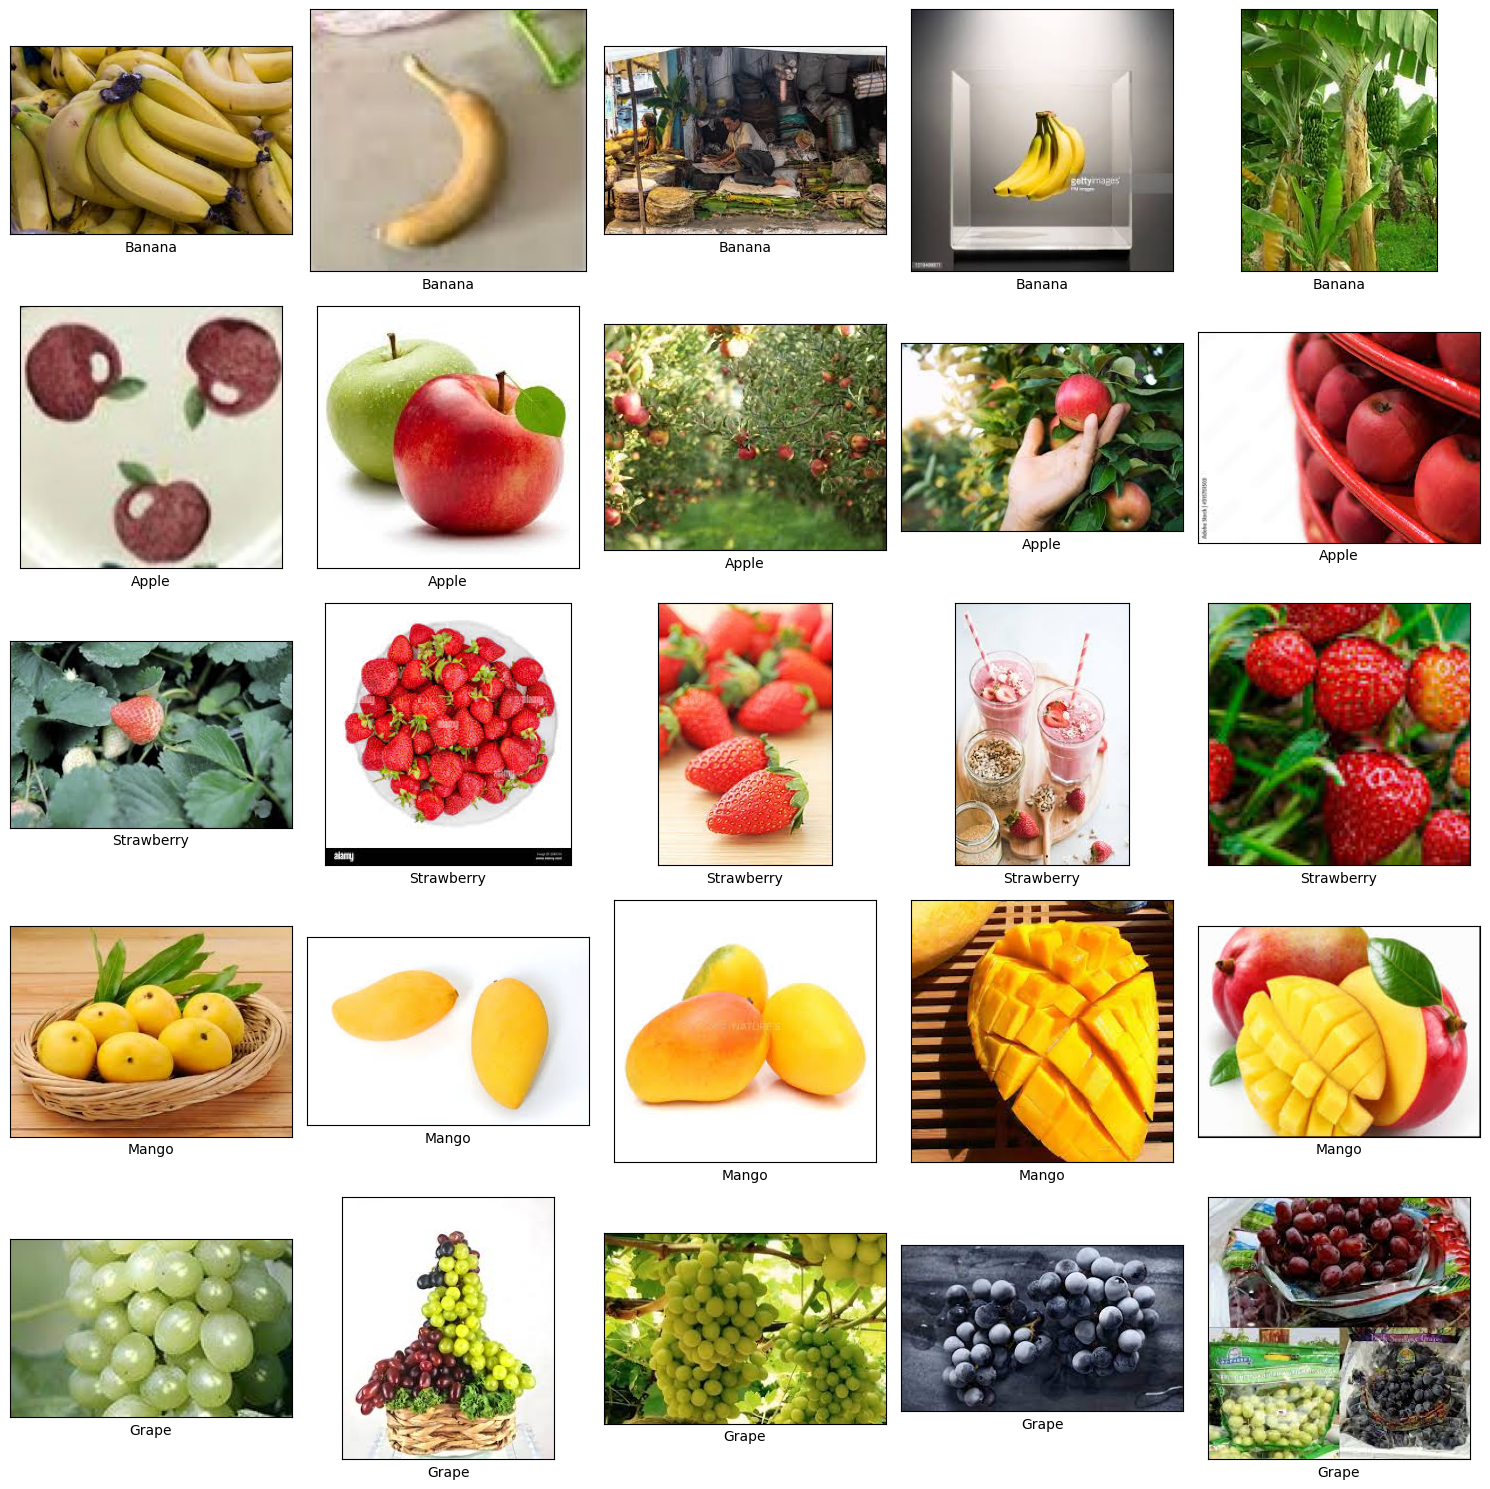

In [8]:
fruit_images = {}

path = "fruits-classification/"
path_sub = os.path.join(path, "dataset_combined")
for i in os.listdir(path_sub):
    fruit_images[i] = os.listdir(os.path.join(path_sub, i))

path_sub = "fruits-classification/dataset_combined"

fig, axs = plt.subplots(len(fruit_images.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(fruit_images[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

#### Visualisasi Distribusi

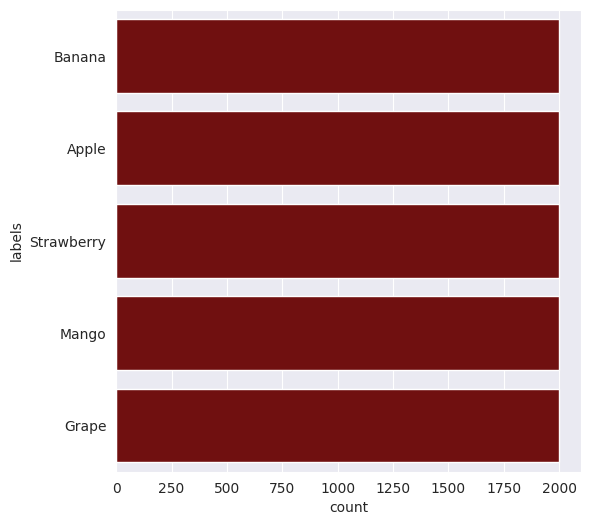

In [9]:
fruit_path = "fruits-classification/dataset_combined"

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(fruit_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label, color="maroon")
plt.show()

#### Split Dataset

In [10]:
mypath= 'fruits-classification/dataset_combined'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
df.groupby(['labels']).size()

,0
labels,
Apple,2000
Banana,2000
Grape,2000
Mango,2000
Strawberry,2000


In [11]:
X= df['path']
y= df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=300)

In [12]:
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})
df_val = pd.DataFrame({'path': X_val, 'labels': y_val, 'set': 'valid'})

In [13]:
print('train size', len(df_tr))
print('test size', len(df_te))
print('valid size', len(df_val))

train size 6400
test size 2000
valid size 1600


In [14]:
df_all = pd.concat([df_tr, df_te, df_val], ignore_index=True)

print(df_all.groupby(['set', 'labels']).size(), '\n')
print(df_all.sample(5))

set    labels    
test   Apple          384
       Banana         411
       Grape          417
       Mango          383
       Strawberry     405
train  Apple         1304
       Banana        1250
       Grape         1276
       Mango         1291
       Strawberry    1279
valid  Apple          312
       Banana         339
       Grape          307
       Mango          326
       Strawberry     316
dtype: int64 

                                                   path  labels    set
1435  fruits-classification/dataset_combined/Grape/G...   Grape  train
6337  fruits-classification/dataset_combined/Banana/...  Banana  train
9935  fruits-classification/dataset_combined/Mango/M...   Mango  valid
2920  fruits-classification/dataset_combined/Banana/...  Banana  train
1496  fruits-classification/dataset_combined/Mango/M...   Mango  train


In [15]:
datasource_path = "fruits-classification/dataset_combined/"
dataset_path = "Dataset-Final/"

In [16]:
for index, row in tqdm(df_all.iterrows(), total=len(df_all)):
    file_path = row['path']
    if not os.path.exists(file_path):
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

    target_dir = os.path.join(dataset_path, row['set'], row['labels'])
    os.makedirs(target_dir, exist_ok=True)

    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(target_dir, destination_file_name)

    if not os.path.exists(file_dest):
        shutil.copy2(file_path, file_dest)

100%|██████████| 10000/10000 [00:02<00:00, 4423.35it/s]


In [17]:
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"
VALID_DIR = "Dataset-Final/valid/"

train_apple = os.path.join(TRAIN_DIR + '/Apple')
train_banana = os.path.join(TRAIN_DIR + '/Banana')
train_grape = os.path.join(TRAIN_DIR + '/Grape')
train_mango = os.path.join(TRAIN_DIR + '/Mango')
train_strawberry = os.path.join(TRAIN_DIR + '/Strawberry')

test_apple = os.path.join(TEST_DIR + '/Apple')
test_banana = os.path.join(TEST_DIR + '/Banana')
test_grape = os.path.join(TEST_DIR + '/Grape')
test_mango = os.path.join(TEST_DIR + '/Mango')
test_strawberry = os.path.join(TEST_DIR + '/Strawberry')

valid_apple = os.path.join(VALID_DIR + '/Apple')
valid_banana = os.path.join(VALID_DIR + '/Banana')
valid_grape = os.path.join(VALID_DIR + '/Grape')
valid_mango = os.path.join(VALID_DIR + '/Mango')
valid_strawberry = os.path.join(VALID_DIR + '/Strawberry')

print("Total number of apple images in training set: ",len(os.listdir(train_apple)))
print("Total number of banana images in training set: ",len(os.listdir(train_banana)))
print("Total number of grape images in training set: ",len(os.listdir(train_grape)))
print("Total number of mango images in training set: ",len(os.listdir(train_mango)))
print("Total number of strawberry images in training set: ",len(os.listdir(train_strawberry)))

print("\nTotal number of apple images in test set: ",len(os.listdir(test_apple)))
print("Total number of banana images in test set: ",len(os.listdir(test_banana)))
print("Total number of grape images in test set: ",len(os.listdir(test_grape)))
print("Total number of mango images in test set: ",len(os.listdir(test_mango)))
print("Total number of strawberry images in test set: ",len(os.listdir(test_strawberry)))

print("\nTotal number of apple images in valid set: ",len(os.listdir(valid_apple)))
print("Total number of banana images in valid set: ",len(os.listdir(valid_banana)))
print("Total number of grape images in valid set: ",len(os.listdir(valid_grape)))
print("Total number of mango images in valid set: ",len(os.listdir(valid_mango)))
print("Total number of strawberry images in valid set: ",len(os.listdir(valid_strawberry)))

Total number of apple images in training set:  1304
Total number of banana images in training set:  1250
Total number of grape images in training set:  1276
Total number of mango images in training set:  1291
Total number of strawberry images in training set:  1279

Total number of apple images in test set:  384
Total number of banana images in test set:  411
Total number of grape images in test set:  417
Total number of mango images in test set:  383
Total number of strawberry images in test set:  405

Total number of apple images in valid set:  312
Total number of banana images in valid set:  339
Total number of grape images in valid set:  307
Total number of mango images in valid set:  326
Total number of strawberry images in valid set:  316


In [18]:
for category in ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']:
    path = os.path.join(VALID_DIR, category)
    print(f"{category}: {len(os.listdir(path))} images")

Apple: 312 images
Banana: 339 images
Grape: 307 images
Mango: 326 images
Strawberry: 316 images


In [19]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest')

val_test_datagen = ImageDataGenerator(rescale=1/255.)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode='categorical',
    shuffle=True)

validation_generator = val_test_datagen.flow_from_directory(
    VALID_DIR,
    batch_size=32,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=(224, 224),
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False)

Found 6400 images belonging to 5 classes.
Found 1600 images belonging to 5 classes.
Found 2000 images belonging to 5 classes.


## Modelling

In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

#### Transfer Learning

In [21]:
base_model = applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True

clf_model = Sequential([
    base_model,
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
])

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

clf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = clf_model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 136s 426ms/step - accuracy: 0.2221 - loss: 1.7287 - val_accuracy: 0.5856 - val_loss: 1.4003 - learning_rate: 1.0000e-05
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.3697 - loss: 1.4715 - val_accuracy: 0.7013 - val_loss: 0.9202 - learning_rate: 1.0000e-05
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 405ms/step - accuracy: 0.5693 - loss: 1.1094 - val_accuracy: 0.7606 - val_loss: 0.6355 - learning_rate: 1.0000e-05
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 402ms/step - accuracy: 0.6643 - loss: 0.8792 - val_accuracy: 0.7987 - val_loss: 0.5327 - learning_rate: 1.0000e-05
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 406ms/step - accuracy: 0.7191 - loss: 0.7509 - val_accuracy: 0.8275 - val_loss: 0.4790 - learning_rate: 1.0000e-05
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 405ms/step - accuracy: 0.7602 - loss: 0.6573 - val_accuracy: 0.8413 - val_loss: 0.4355 - learning_rate: 1.0000e-05
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 4

## Evaluasi dan Visualisasi

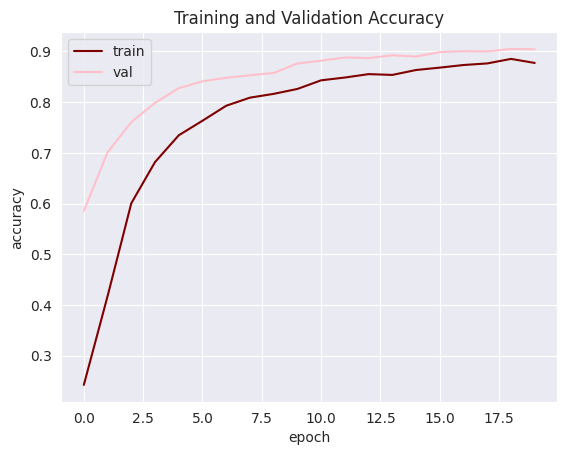

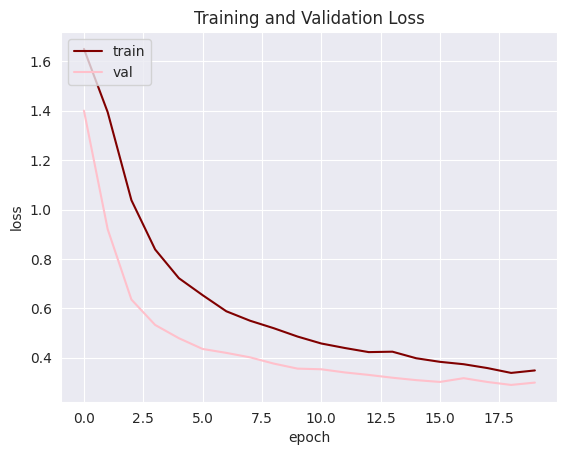

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'maroon')
plt.plot(epochs, val_acc, 'pink')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'maroon')
plt.plot(epochs, val_loss, 'pink')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validation Loss')
plt.show()

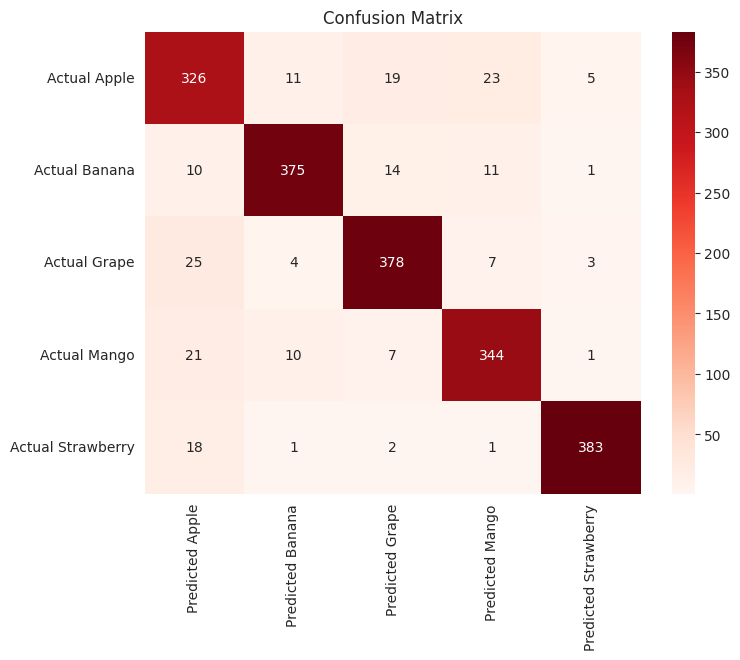


Classification Report:

              precision    recall  f1-score   support

       Apple     0.8150    0.8490    0.8316       384
      Banana     0.9352    0.9124    0.9236       411
       Grape     0.9000    0.9065    0.9032       417
       Mango     0.8912    0.8982    0.8947       383
  Strawberry     0.9746    0.9457    0.9599       405

    accuracy                         0.9030      2000
   macro avg     0.9032    0.9023    0.9026      2000
weighted avg     0.9043    0.9030    0.9035      2000



In [23]:
test_generator.reset()

preds_final = clf_model.predict(test_generator, verbose=0)
y_pred = np.argmax(preds_final, axis=1)
y_true = test_generator.classes

cm = pd.DataFrame(confusion_matrix(y_true, y_pred),
                  index=["Actual Apple", "Actual Banana", "Actual Grape", "Actual Mango", "Actual Strawberry"],
                  columns=["Predicted Apple", "Predicted Banana", "Predicted Grape", "Predicted Mango", "Predicted Strawberry"])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
                            target_names=['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry'],
                            digits=4))


Saving fruit_testing.jpg to fruit_testing (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


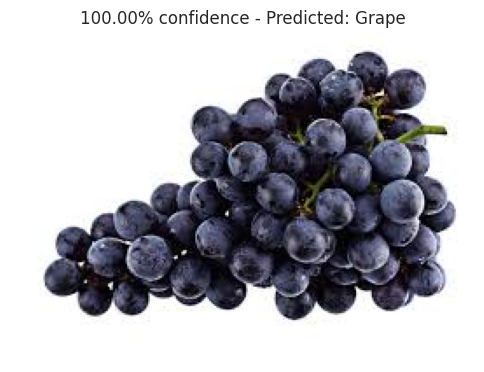

In [ ]:
uploaded = files.upload()

class_labels = list(test_generator.class_indices.keys())

for fn in uploaded.keys():
    test_img = image.load_img(fn, target_size=(224, 224))
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img / 255.0
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    prediction = clf_model.predict(pp_test_img)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.figure(figsize=(6, 6))
    plt.axis('off')
    plt.title(f"{confidence*100:.2f}% confidence - Predicted: {class_labels[predicted_class]}")
    plt.imshow(image.load_img(fn))
    plt.show()

## Konversi Model

In [ ]:
submission_dir = "submission"
os.makedirs(f"{submission_dir}/TFJS", exist_ok=True)
os.makedirs(f"{submission_dir}/TF-Lite", exist_ok=True)
os.makedirs(f"{submission_dir}/SavedModel", exist_ok=True)

saved_model_path = os.path.join(submission_dir, "SavedModel")
tf.saved_model.save(clf_model, saved_model_path)
print("Model disimpan sebagai SavedModel")

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

tflite_path = f"{submission_dir}/TF-Lite/model.TF-Lite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("Model dikonversi ke TF-Lite")

class_labels = ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
label_path = f"{submission_dir}/TF-Lite/label.txt"
with open(label_path, "w") as f:
    for label in class_labels:
        f.write(label + "\n")
print("Label kelas disimpan dalam label.txt")

tfjs_path = f"{submission_dir}/TFJS"
tfjs.converters.convert_tf_saved_model(saved_model_path, tfjs_path)
print("Model dikonversi ke TFJS")

shutil.make_archive("submission", 'zip', "submission")
files.download("submission.zip")
print("Folder submission.zip berhasil dibuat dan siap di-download!")


✅ Model disimpan sebagai SavedModel
✅ Model dikonversi ke TF-Lite
✅ Label kelas disimpan dalam label.txt
✅ Model dikonversi ke TFJS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Folder submission.zip berhasil dibuat dan siap di-download!


In [ ]:
!mkdir -p /content/LibProject

In [ ]:
!ls /content/

 Dataset-Final		    'fruit_testing (1).jpg'   sample_data
 fruits-classification	     fruit_testing.jpg	      submission
 fruits-classification.zip   LibProject		      submission.zip


In [ ]:
!pipreqs /content/LibProject --force --scan-notebooks

INFO: Successfully saved requirements file in /content/LibProject/requirements.txt


In [ ]:
from google.colab import files
files.download("/content/LibProject/requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)

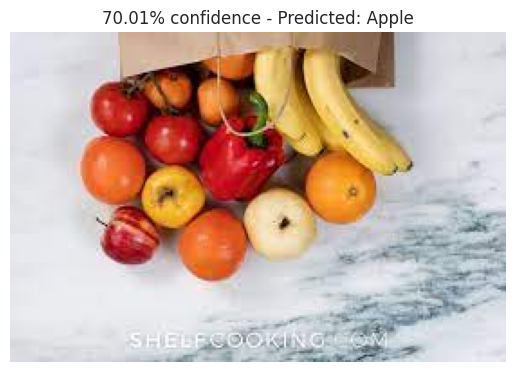

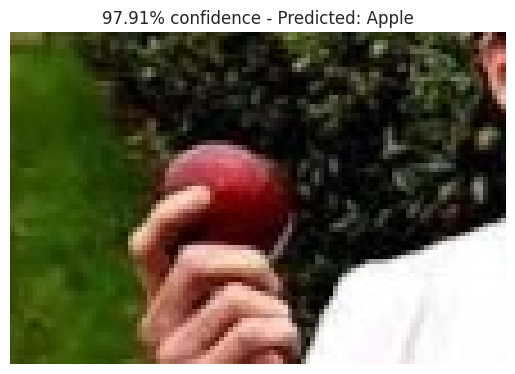

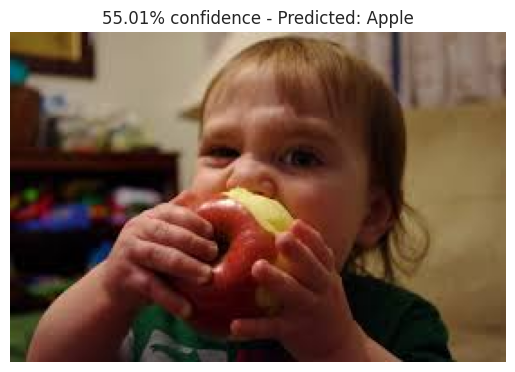

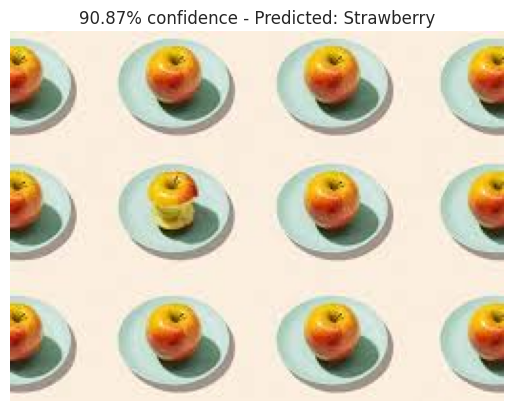

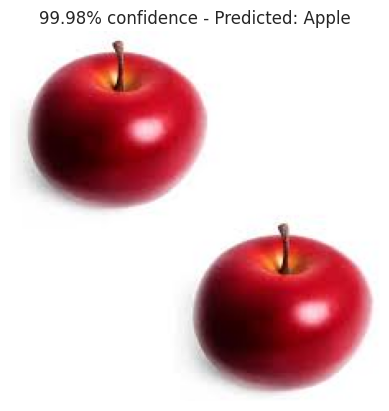

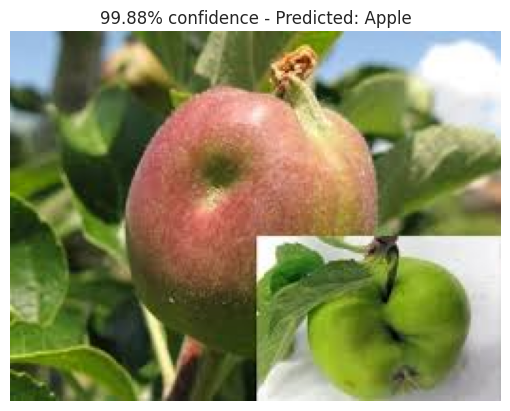

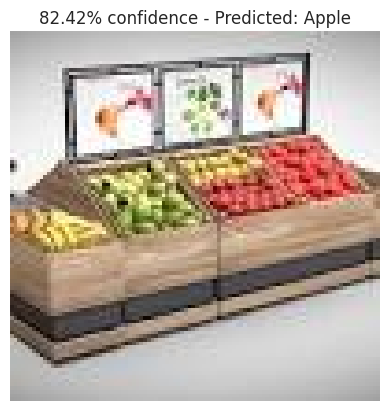

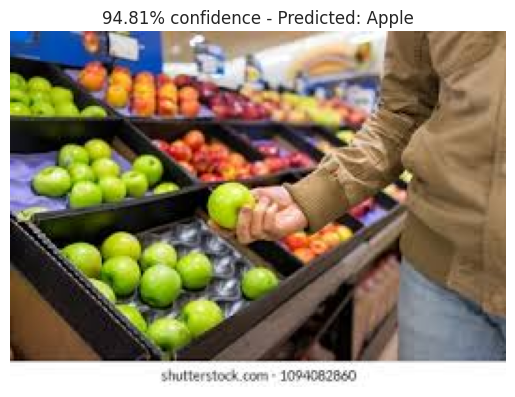

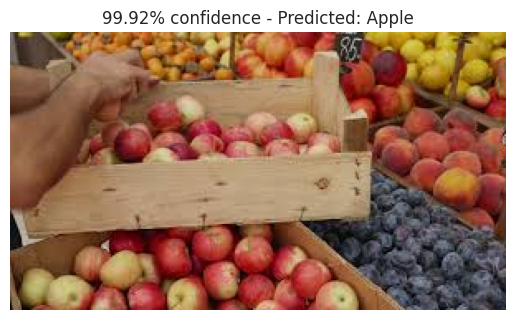

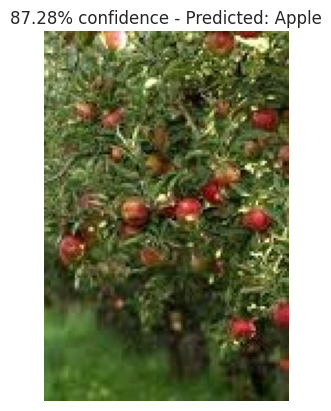

In [24]:
for index, probability in enumerate(preds_final[:10]):
    image_path = TEST_DIR + "/" + test_generator.filenames[index]
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.axis("off")

    predicted_class = np.argmax(probability)
    confidence = np.max(probability)
    label = test_generator.class_indices
    class_labels = list(label.keys())

    plt.title(f"{confidence*100:.2f}% confidence - Predicted: {class_labels[predicted_class]}")
    plt.show()